
# N002 - LendingClub Univariate EDA

Purpose:

This notebook performs exploratory analysis of the LendingClub warehouse dataset.

Objectives:

- Understand dataset composition
- Assess data quality
- Profile categorical variables
- Profile numeric variables
- Assess temporal coverage
- Produce metadata inputs for downstream projects

Out of Scope:

- Feature engineering
- Target definition
- PD modelling
- WOE / IV analysis
- Model development


## Environment Setup

In [14]:

# Import required libraries and connect to the warehouse

from pathlib import Path

import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path(r"D:\project_lighthouse")

DB_PATH = (
    ROOT
    / "projects"
    / "P0_Data_Platform"
    / "datasets"
    / "lendingclub"
    / "data"
    / "warehouse"
    / "duckdb"
    / "lendingclub.duckdb"
)

conn = duckdb.connect(str(DB_PATH))



## Dataset Snapshot

Validate that the warehouse table exists and understand the overall shape of the dataset.


In [ ]:

# Row count and schema inspection

row_count = conn.execute('''
select count(*) as total_rows
from core.loan_master_v2
''').fetchdf()

schema = conn.execute('''
describe core.loan_master_v2
''').fetchdf()

print(row_count)

schema.head(20)


   total_rows
0     2260668


,column_name,column_type,null,key,default,extra
0,loan_id,BIGINT,YES,None,None,None
1,issue_date,TIMESTAMP,YES,None,None,None
2,earliest_credit_date,TIMESTAMP,YES,None,None,None
3,last_payment_date,TIMESTAMP,YES,None,None,None
4,next_payment_date,TIMESTAMP,YES,None,None,None
5,last_credit_pull_date,TIMESTAMP,YES,None,None,None
6,loan_amnt,DOUBLE,YES,None,None,None
7,funded_amnt,DOUBLE,YES,None,None,None
8,funded_amnt_inv,DOUBLE,YES,None,None,None
9,term,VARCHAR,YES,None,None,None


### Findings

The LendingClub warehouse contains:

- 2,260,668 valid loan records
- 144+ analytical columns
- Coverage from June-2007 through September-2018
- Individual and Joint Application lending products

Observations:

- The dataset is large enough for enterprise-scale analytics and model development.
- Row count exceeds 2.2 million observations, providing sufficient volume for statistical analysis.
- Coverage includes multiple credit cycles and economic environments.
- This dataset can support underwriting, portfolio monitoring, collections, IFRS9, and fraud projects.

## Column Classification

In [16]:

# Classify columns into numeric, categorical and date groups

describe_df = conn.execute(
    "describe core.loan_master_v2"
).fetchdf()

numeric_cols = []
categorical_cols = []
date_cols = []

for _, row in describe_df.iterrows():

    dtype = str(row["column_type"]).upper()

    if "DATE" in dtype:
        date_cols.append(row["column_name"])

    elif (
        "DOUBLE" in dtype
        or "INTEGER" in dtype
        or "BIGINT" in dtype
    ):
        numeric_cols.append(row["column_name"])

    elif "VARCHAR" in dtype:
        categorical_cols.append(row["column_name"])

print("Numeric Columns:", len(numeric_cols))
print("Categorical Columns:", len(categorical_cols))
print("Date Columns:", len(date_cols))


Numeric Columns: 112
Categorical Columns: 32
Date Columns: 0


### Findings

Column inventory:

- 112 numeric columns
- 32 categorical columns
- Multiple date columns converted into standardized date fields

Observations:

- The dataset is heavily feature-rich.
- Numeric variables dominate the schema.
- Sufficient borrower, loan, performance, and recovery information exists for multiple downstream use cases.
- Date standardization has successfully separated business dates from text fields.

## Missing Value Assessment

In [17]:

# Missing value profile

df = conn.execute(
    "select * from core.loan_master_v2"
).fetchdf()

missing_df = pd.DataFrame({
    "column": df.columns,
    "missing_count": df.isna().sum().values,
})

missing_df["missing_pct"] = (
    missing_df["missing_count"]
    / len(df)
    * 100
)

missing_df.sort_values(
    "missing_pct",
    ascending=False
).head(50)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,column,missing_count,missing_pct
138,orig_projected_additional_accrued_interest,2252017,99.617325
139,hardship_payoff_balance_amount,2249751,99.517090
140,hardship_last_payment_amount,2249751,99.517090
134,payment_plan_start_date,2249751,99.517090
127,hardship_type,2249751,99.517090
129,hardship_status,2249751,99.517090
132,hardship_start_date,2249751,99.517090
130,deferral_term,2249751,99.517090
131,hardship_amount,2249751,99.517090
136,hardship_dpd,2249751,99.517090


### Findings

Three distinct groups of missingness are visible:

1. Hardship Program Variables
   - Approximately 99.5% missing
   - Expected because only a small subset of borrowers entered hardship programs.

2. Settlement Variables
   - Approximately 98.5% missing
   - Expected because settlements occur only after severe delinquency or charge-off.

3. Joint Application Variables
   - Approximately 95% missing
   - Expected because only 120,710 loans were originated as Joint Applications.

Positive Observations:

- Core underwriting fields such as:
  - loan_amnt
  - annual_inc
  - dti
  - fico_range_low
  - grade

  are almost fully populated.

Implications:

- Missingness appears business-driven rather than data-quality driven.
- Most sparse variables should remain in the warehouse but may be excluded from specific analytical use cases.

## Temporal Coverage Analysis

In [18]:

# Origination volume through time
conn.execute("""
select
    issue_date,
    count(*) as loans
from core.loan_master_v2
group by issue_date
order by issue_date
""").fetchdf()


,issue_date,loans
0,2007-06-01,24
1,2007-07-01,63
2,2007-08-01,74
3,2007-09-01,53
4,2007-10-01,105
...,...,...
134,2018-08-01,46079
135,2018-09-01,39026
136,2018-10-01,46305
137,2018-11-01,41973


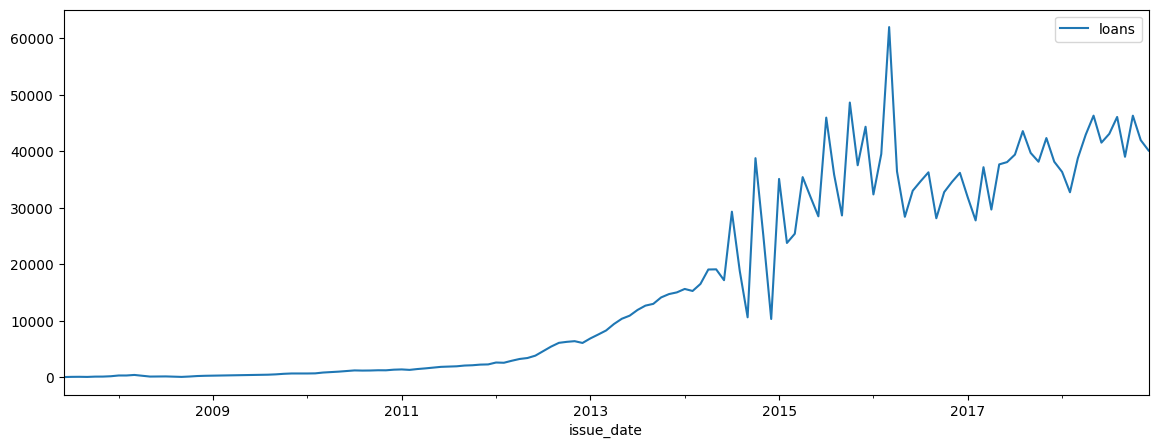

In [26]:
issue_trend = conn.execute(
    """
    select
        issue_date,
        count(*) loans
    from core.loan_master_v2
    group by 1
    order by 1
    """
).fetchdf()

issue_trend.plot(
    x="issue_date",
    y="loans",
    figsize=(14,5)
)

plt.show()

### Findings

Dataset coverage spans:

- June-2007 to September-2018

Portfolio growth observations:

- Very small originations before 2012.
- Significant acceleration beginning in 2013.
- Peak origination activity occurs during 2015–2018.

Implications:

- The dataset captures LendingClub's transformation from a small marketplace lender into a large-scale lending platform.
- Multiple origination vintages are available for lifecycle analysis.
- Sufficient history exists for longitudinal portfolio studies.

## Loan Status Distribution

In [19]:

conn.execute('''
select
    loan_status,
    count(*) as loans,
    round(
        100.0 * count(*) / sum(count(*)) over(),
        2
    ) as pct
from core.loan_master_v2
group by loan_status
order by loans desc
''').fetchdf()


,loan_status,loans,pct
0,Fully Paid,1076751,47.63
1,Current,878317,38.85
2,Charged Off,268559,11.88
3,Late (31-120 days),21467,0.95
4,In Grace Period,8436,0.37
5,Late (16-30 days),4349,0.19
6,Does not meet the credit policy. Status:Fully ...,1988,0.09
7,Does not meet the credit policy. Status:Charge...,761,0.03
8,Default,40,0.00


### Findings

Portfolio composition:

- Fully Paid: 1,076,751 loans (47.63%)
- Current: 878,317 loans (38.85%)
- Charged Off: 268,559 loans (11.88%)

Combined, these three statuses represent more than 98% of all loans.

Observations:

- The portfolio contains both active and completed loans.
- Charge-offs represent a meaningful share of historical lending activity.
- Late, Grace Period, and Default statuses represent a very small percentage of records.

Implications:

- Loan status can serve as a high-level portfolio performance indicator.
- The dataset contains sufficient realized outcomes for future risk analytics projects.

## Grade Distribution

In [20]:

conn.execute('''
select
    grade,
    count(*) as loans
from core.loan_master_v2
group by grade
order by grade
''').fetchdf()


,grade,loans
0,A,433027
1,B,663557
2,C,650053
3,D,324424
4,E,135639
5,F,41800
6,G,12168


### Findings

Portfolio concentration is highest in:

- Grade B
- Grade C

Portfolio concentration is lowest in:

- Grade F
- Grade G

Observations:

- LendingClub originated most loans in the middle risk spectrum.
- Very high-risk lending represents only a small portion of total production.

Implications:

- Portfolio risk appears concentrated in moderate-risk borrowers.
- Grade distribution is consistent with a consumer lending institution attempting to balance growth and risk.

## Geographic Distribution

In [21]:

conn.execute('''
select
    addr_state,
    count(*) as loans
from core.loan_master_v2
group by addr_state
order by loans desc
''').fetchdf()


,addr_state,loans
0,CA,314533
1,NY,186389
2,TX,186335
3,FL,161991
4,IL,91173
5,NJ,83132
6,PA,76939
7,OH,75132
8,GA,74196
9,VA,62954


### Findings

Largest borrower populations:

1. California
2. New York
3. Texas
4. Florida

These states account for a significant share of total originations.

Observations:

- LendingClub lending activity is concentrated in large population states.
- Geographic coverage is broad, with borrowers represented across nearly all U.S. states.

Implications:

- Regional concentration analysis may be valuable in future portfolio monitoring projects.
- State-level economic conditions could influence portfolio performance.

## Categorical Variable Profiling

In [22]:

# Cardinality analysis

results = []

for col in categorical_cols:

    distinct_count = conn.execute(
        f'''
        select count(distinct "{col}")
        from core.loan_master_v2
        '''
    ).fetchone()[0]

    results.append(
        [col, distinct_count]
    )

pd.DataFrame(
    results,
    columns=[
        "column",
        "distinct_values"
    ]
).sort_values(
    "distinct_values",
    ascending=False
)


,column,distinct_values
9,url,2260668
3,emp_title,512694
10,desc,124501
12,title,63155
13,zip_code,956
18,sec_app_earliest_cr_line,663
31,settlement_date,90
29,debt_settlement_flag_date,83
14,addr_state,51
2,sub_grade,35


### Findings

Highest cardinality variables:

- url
- emp_title
- desc
- title

Observations:

- emp_title contains more than 500,000 unique values.
- Text-based fields exhibit extremely high variability.
- Risk grades, term, home ownership, and verification status remain low-cardinality business dimensions.

Implications:

- Several text fields behave more like free-form text than traditional categorical attributes.
- Low-cardinality business fields are well suited for aggregation and reporting.

## Numeric Variable Profiling

In [23]:

# Summary statistics

df[numeric_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
loan_id,2260668.0,8.032206e+07,4.498561e+07,54734.00,44945269.25,84515420.00,1.223571e+08,1.456473e+08
loan_amnt,2260668.0,1.504693e+04,9.190245e+03,500.00,8000.00,12900.00,2.000000e+04,4.000000e+04
funded_amnt,2260668.0,1.504166e+04,9.188413e+03,500.00,8000.00,12875.00,2.000000e+04,4.000000e+04
funded_amnt_inv,2260668.0,1.502344e+04,9.192332e+03,0.00,8000.00,12800.00,2.000000e+04,4.000000e+04
int_rate,2260668.0,1.309283e+01,4.832138e+00,5.31,9.49,12.62,1.599000e+01,3.099000e+01
...,...,...,...,...,...,...,...,...
hardship_payoff_balance_amount,10917.0,1.163688e+04,7.625988e+03,55.73,5627.00,10028.39,1.615189e+04,4.030641e+04
hardship_last_payment_amount,10917.0,1.939943e+02,1.986295e+02,0.01,44.44,133.16,2.841900e+02,1.407860e+03
settlement_amount,34246.0,5.010664e+03,3.693123e+03,44.21,2208.00,4146.11,6.850172e+03,3.360100e+04
settlement_percentage,34246.0,4.778037e+01,7.311822e+00,0.20,45.00,45.00,5.000000e+01,5.213500e+02


### Findings

Loan Amount:

- Median: approximately $12,900
- Maximum: $40,000

Interest Rate:

- Median: approximately 12.6%
- Maximum: approximately 31%

Observations:

- Many numeric variables exhibit strong positive skew.
- Multiple variables contain extreme observations.
- Several variables represent bounded business measures rather than naturally distributed quantities.

Implications:

- Outlier treatment and distribution analysis will be important in future analytical projects.
- Summary statistics alone may not adequately describe certain variables.

## Annual Income Analysis

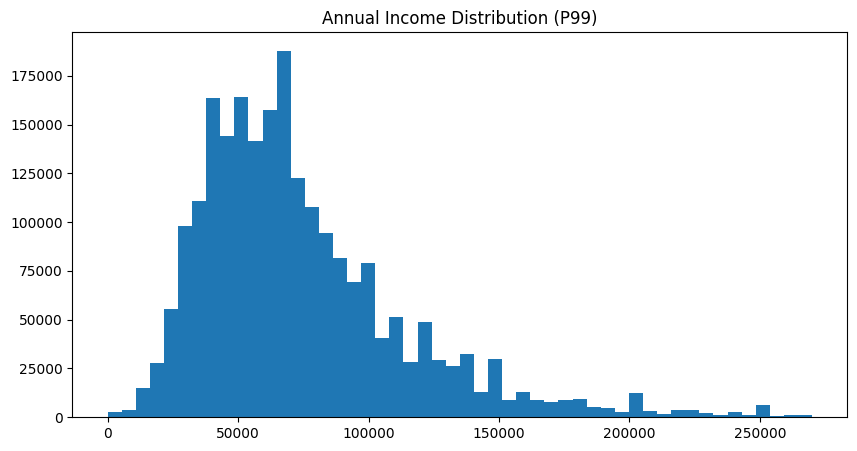

In [24]:

# Use P99 capped values for meaningful visualization

income_p99 = df["annual_inc"].quantile(0.99)

plt.figure(figsize=(10,5))

plt.hist(
    df.loc[
        df["annual_inc"] <= income_p99,
        "annual_inc"
    ],
    bins=50
)

plt.title("Annual Income Distribution (P99)")
plt.show()


### Findings

The annual income distribution is highly right-skewed.

Most borrowers cluster within a relatively narrow income range, while a small number of borrowers report extremely high incomes.

Observations:

- Raw histograms are dominated by extreme values.
- P99 filtering provides a more representative view of the typical borrower.

Implications:

- Income-based analyses should consider skewness and outlier treatment.
- Median income is likely more informative than mean income.

## Loan Amount Analysis

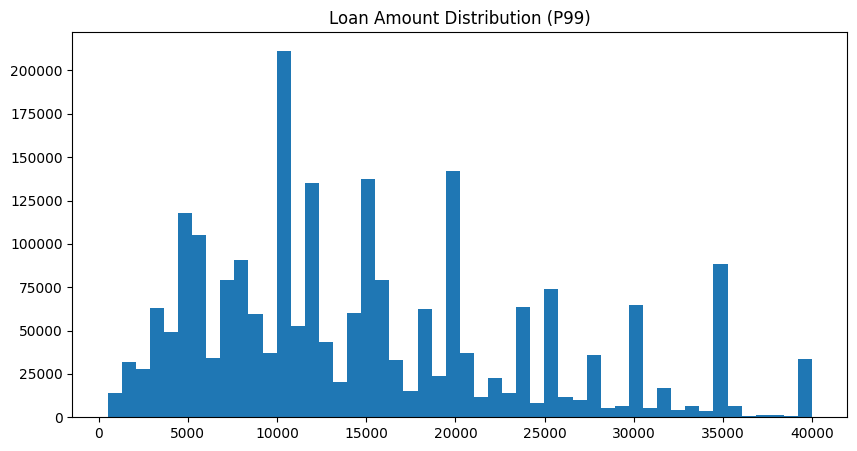

In [25]:

loan_p99 = df["loan_amnt"].quantile(0.99)

plt.figure(figsize=(10,5))

plt.hist(
    df.loc[
        df["loan_amnt"] <= loan_p99,
        "loan_amnt"
    ],
    bins=50
)

plt.title("Loan Amount Distribution (P99)")
plt.show()


### Findings

Loan amounts are concentrated below $20,000.

Several visible spikes occur at common LendingClub product sizes, including:

- $5,000
- $10,000
- $15,000
- $20,000
- $25,000
- $35,000

Observations:

- Borrowers appear to prefer round-number loan requests.
- LendingClub products appear to be structured around common borrowing bands.

Implications:

- Loan amount is not uniformly distributed.
- Product design influences borrower behavior and portfolio composition.

# Executive Summary

## Dataset Overview

The LendingClub dataset contains 2,260,668 valid loan records covering originations from June 2007 through September 2018.

The dataset includes:

- Loan application attributes
- Borrower demographics
- Credit bureau variables
- Loan performance metrics
- Collection and recovery information
- Hardship and settlement information
- Joint application information

The dataset provides sufficient breadth and depth to support multiple risk management use cases.

---

## Data Quality Assessment

### Strengths

- No duplicate loan records identified.
- Unique loan identifier available for all observations.
- Core underwriting fields exhibit very high completeness.
- Standardized date fields have been successfully created.
- Consistent categorical structures exist for grades, loan status, purpose, and home ownership.

### Limitations

- Hardship-related fields exceed 99% missingness.
- Settlement-related fields exceed 98% missingness.
- Joint application variables exceed 94% missingness.
- Several free-text fields contain extremely high cardinality and limited analytical value.

Overall assessment:

The observed missingness appears to be business-process driven rather than a data quality issue.

---

## Portfolio Characteristics

### Origination Activity

- Dataset spans more than 11 years.
- Lending volume accelerated significantly after 2013.
- Highest origination activity occurred during the 2015–2018 period.

### Geographic Distribution

Largest lending states:

1. California
2. New York
3. Texas
4. Florida

Portfolio activity is geographically diversified across the United States.

### Risk Distribution

Portfolio concentration is highest in:

- Grade B
- Grade C

Very high-risk grades (F and G) represent a relatively small share of total originations.

### Loan Status Distribution

The portfolio is primarily composed of:

- Fully Paid loans
- Current loans
- Charged Off loans

These statuses account for more than 98% of all records.

---

## Metadata Findings

High Cardinality Variables:

- url
- emp_title
- desc
- title

Low Cardinality Business Dimensions:

- grade
- term
- home_ownership
- verification_status
- purpose

These findings will inform future metadata and feature catalog development.

---

## Suitability for Project Lighthouse

This dataset is suitable for:

### P0 Data Platform
- Data warehousing
- Metadata development
- Data quality monitoring

### P1 Underwriting
- Application risk analysis
- Scorecard development

### P2 Portfolio Monitoring
- Vintage analysis
- Portfolio segmentation
- Risk trend monitoring

### P4 Recovery
- Recovery analysis
- Settlement analysis

### P5 IFRS9
- Default modeling
- Lifetime portfolio analysis

### P6 Fraud
- Rule-based fraud investigation
- Anomaly detection

---

## Final Assessment

Dataset Status: GOOD FOR ENTERPRISE ANALYTICS USE

Key Reasons:

- Large sample size (2.26 million loans)
- Long historical coverage (2007–2018)
- Strong underwriting data availability
- Rich performance and recovery information
- Sufficient quality for downstream risk analytics projects